# Same picture but with people faces "blurred"

https://www.geeksforgeeks.org/python/how-to-blur-faces-in-images-using-opencv-in-python/

TODO different face detection model

In [3]:
import os

In [14]:
base_dir = "C:/Users/lchtu/OneDrive/Desktop/Persoonlijk/werk/RA InfoLAB/Data Transformation/visual-data-transformations/"
image_paths = ["data/FFF_hun/2019-02-26_08-01-54_UTC.jpg","data/FFF_hun/2019-03-02_10-27-43_UTC.jpg", "data/FFF_hun/big_face.jpg","data/FFF_hun/group_marching.jpg","data/FFF_hun/tilted_face.jpg","data/FFF_hun/tilted_up_face.jpg","data/FFF_hun/profile_face.jpg"]
for i,image_file in enumerate(image_paths):
    image_paths[i] = os.path.join(base_dir,image_file)

## Retina

In [10]:
# !pip install retina-face
!pip uninstall tf-keras

^C


In [5]:
from retinaface import RetinaFace
import cv2
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
SIGMA = 30
PIXEL_SIZE = 10
FACE_H = 0.55
FACE_W = 0.45

In [ ]:
def obstruct_faces(image_file, obstruction_type, sigma = SIGMA, pixel_size = PIXEL_SIZE):
    """
    Detect and obstruct faces in an image.

    Args:
        image (PIL.Image): Input image.
        obstruction_type (str): Method used to obstruct detected faces.
            Supported methods:
                "blur"     : Gaussian blur
                "pixelate" : Pixelation
                "block"    : Black out the face
        sigma (float, optional): Standard deviation of the Gaussian kernel. Larger values
            produce stronger blur. Defaults to 30.
        pixel_size (int, optional): Width and height of the reduced representation used during pixelation.
            Smaller values produce stronger pixelation. Defaults to 10.

    Returns:
        numpy.ndarray: The processed image in RGB format.
    """
    image = np.array(image.convert("RGB"))

    if image is None:
        raise ValueError(f"Could not load image: {image_file}")

    faces = RetinaFace.detect_faces(image_file)
    print(f"Detected {len(faces)} face(s)")

    if obstruction_type == "blur":
        image = blur(faces,image,sigma=sigma)
    elif obstruction_type == "pixelate":
        image = pixelate(faces,image,pixel_size=pixel_size)
    elif obstruction_type == "block":
        image = block_out(faces,image)
    return Image.fromarray(image)


def blur(faces, image, sigma = SIGMA):
    """
    A Gaussian blur is applied to the detected mask for each detected face. 

    Args:
        faces (dict): Face detections returned by the face detector. Containing at least:
            facial_area (list[int]): Face bounding box in the format [x1, y1, x2, y2].
            landmarks (dict): RetinaFace facial landmarks containing 'right_eye' and 'left_eye' coordinates.
        image (numpy.ndarray): Image containing the detected faces.
        sigma (float, optional): Standard deviation of the Gaussian kernel. Larger values
            produce stronger blur. Defaults to 30.

    Returns:
        numpy.ndarray: The input image with the detected face regions blurred.

    Notes:
        The kernel size is automatically determined by OpenCV because (0, 0) is provided as the kernel size.
    """
    for face in range(len(faces)):
        identity = faces[f"face_{face + 1}"]
        print(identity)
        facial_area = identity["facial_area"]
        landmarks = identity["landmarks"]
        x1, y1, x2, y2 = facial_area
        w, h = x2 - x1, y2 - y1
        roi = image[y1:y2, x1:x2]
        blurred_roi = cv2.GaussianBlur(roi,(0, 0),sigma)
        mask = np.ones((h, w), dtype=np.uint8) * 255
        roi[mask == 255] = blurred_roi[mask == 255]
        image[y1:y2, x1:x2] = roi
    return image


def pixelate(faces, image, pixel_size = PIXEL_SIZE):
    """
    Pixelate is applied to the detected mask for each detected face. 

    Args:
        faces (dict): Face detections returned by the face detector. Containing at least:
            facial_area (list[int]): Face bounding box in the format [x1, y1, x2, y2].
            landmarks (dict): RetinaFace facial landmarks containing 'right_eye' and 'left_eye' coordinates.
        image (numpy.ndarray): Image containing the detected faces.
        pixel_size (int, optional): Width and height of the reduced representation used during pixelation.
            Smaller values produce stronger pixelation. Defaults to 10.

    Returns:
        numpy.ndarray: The input image with the detected face regions pixelated.
    """
    for face in range(len(faces)):
        identity = faces[f"face_{face + 1}"]
        facial_area = identity["facial_area"]
        x1, y1, x2, y2 = facial_area
        w, h = x2 - x1, y2 - y1
        roi = image[y1:y2, x1:x2]
        small = cv2.resize(roi,(pixel_size, pixel_size),interpolation=cv2.INTER_LINEAR)
        pixelated_roi = cv2.resize(small,(w, h),interpolation=cv2.INTER_NEAREST)
        mask = np.ones((h, w), dtype=np.uint8) * 255
        roi[mask == 255] = pixelated_roi[mask == 255]
        image[y1:y2, x1:x2] = roi
    return image


def block_out(faces, image):
    """
    Black out is applied to the detected area mask for each detected face. 

    Args:
        faces (dict): Face detections returned by the face detector. Containing at least:
            facial_area (list[int]): Face bounding box in the format [x1, y1, x2, y2].
            landmarks (dict): RetinaFace facial landmarks containing 'right_eye' and 'left_eye' coordinates.
        image (numpy.ndarray): Image containing the detected faces.

    Returns:
        numpy.ndarray: The input image with the detected face regions replaced by black pixels.
    """
    for face in range(len(faces)):
        identity = faces[f"face_{face + 1}"]
        facial_area = identity["facial_area"]
        x1, y1, x2, y2 = facial_area
        w, h = x2 - x1, y2 - y1
        roi = image[y1:y2, x1:x2]
        mask = np.ones((h, w), dtype=np.uint8) * 255
        roi[mask == 255] = 0
        image[y1:y2, x1:x2] = roi
    return image

Detected 5 face(s)


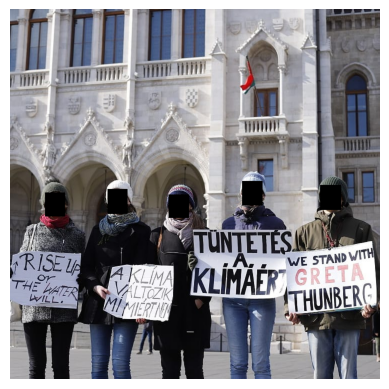

Detected 4 face(s)


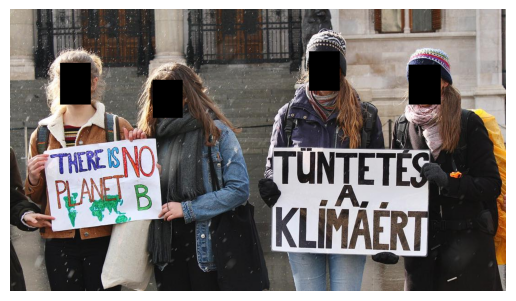

Detected 1 face(s)


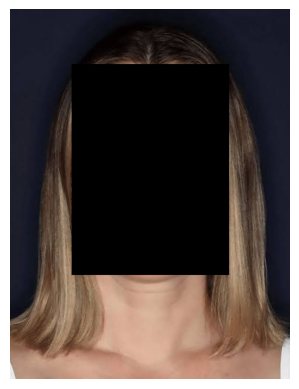

Detected 30 face(s)


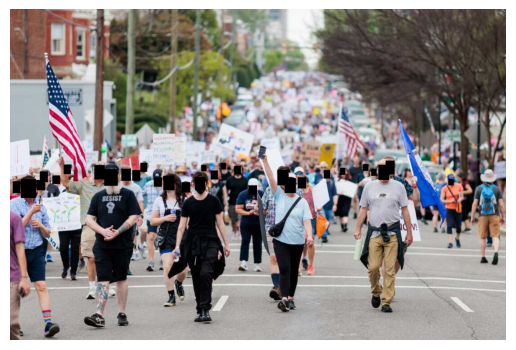

Detected 1 face(s)


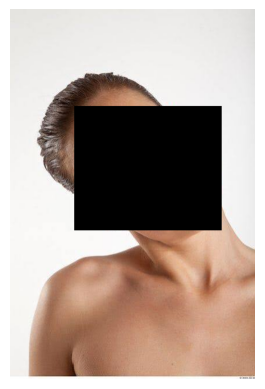

Detected 1 face(s)


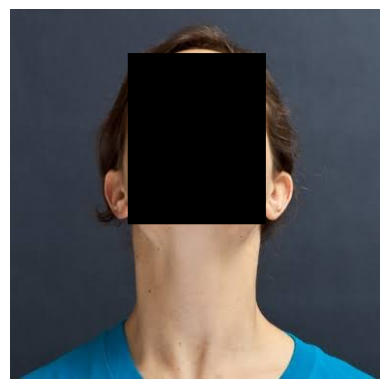

Detected 1 face(s)


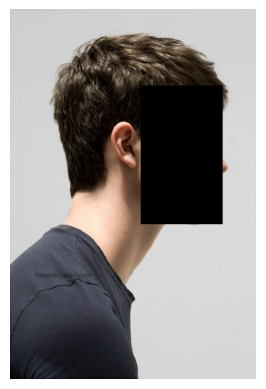

In [30]:
for image_path in image_paths:
    # 'blur', 'pixelate', 'block'
    image = obstruct_faces(image_path, obstruction_type='block')
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

## Obstructions

In [ ]:
# def face_mask(facial_area,landmarks,face_h=FACE_H,face_w=FACE_W):
#     """
#     Create an elliptical mask approximating a detected face, rotated
#     according to the angle of the eyes.

#     Args:
#         facial_area (list[int]): Face bounding box in the format
#             [x1, y1, x2, y2].
#         landmarks (dict): RetinaFace facial landmarks containing
#             'right_eye' and 'left_eye' coordinates.
#         face_h (float, optional): Vertical radius of the ellipse as a
#             proportion of the bounding-box height.
#         face_w (float, optional): Horizontal radius of the ellipse as a
#             proportion of the bounding-box width.

#     Returns:
#         numpy.ndarray: Binary uint8 mask of the detected face region.
#     """
#     x1, y1, x2, y2 = facial_area
#     w = x2 - x1
#     h = y2 - y1
#     mask = np.zeros((h, w), dtype=np.uint8)
#     center = (w // 2, h // 2)
#     axes = (int(w * face_w),int(h * face_h))
#     right_eye = landmarks["right_eye"]
#     left_eye = landmarks["left_eye"]
#     dx = left_eye[0] - right_eye[0]
#     dy = left_eye[1] - right_eye[1]
#     angle = np.degrees(np.arctan2(dy, dx))
#     cv2.rectangle(mask, (x2, y2), (x1, y1), (255, 255, 255), 1)
#     # cv2.ellipse(mask,center,axes,angle,0,360,255,-1)
#     return mask


# def blur(faces, image, sigma = SIGMA, face_h = FACE_H, face_w = FACE_W):
#     """
#     A Gaussian blur is applied to an elliptical mask for each detected face. 

#     Args:
#         faces (dict): Face detections returned by the face detector. Containing at least:
#             facial_area (list[int]): Face bounding box in the format [x1, y1, x2, y2].
#             landmarks (dict): RetinaFace facial landmarks containing 'right_eye' and 'left_eye' coordinates.
#         image (numpy.ndarray): Image containing the detected faces.
#         sigma (float, optional): Standard deviation of the Gaussian kernel. Larger values
#             produce stronger blur. Defaults to 30.
#         face_h (float, optional): Vertical radius of the face mask as a proportion of the bounding-box height.
#             Larger values produce larger box borders. Defaults to 0.48.
#         face_w (float, optional): Horizontal radius of the face mask as a proportion of the bounding-box width.
#             Larger values produce larger box borders. Defaults to 0.42.

#     Returns:
#         numpy.ndarray: The input image with the detected face regions blurred.

#     Notes:
#         The kernel size is automatically determined by OpenCV because (0, 0) is provided as the kernel size.
#     """
#     for face in range(len(faces)):
#         identity = faces[f"face_{face + 1}"]
#         print(identity)
#         facial_area = identity["facial_area"]
#         landmarks = identity["landmarks"]
#         x1, y1, x2, y2 = facial_area
#         w = x2 - x1
#         h = y2 - y1
#         roi = image[y1:y2, x1:x2]
#         blurred_roi = cv2.GaussianBlur(roi,(0, 0),sigma)
#         mask = face_mask(facial_area,landmarks,face_h=face_h,face_w=face_w)
#         roi[mask == 255] = blurred_roi[mask == 255]
#         image[y1:y2, x1:x2] = roi
#     return image


# def pixelate(faces, image, pixel_size = PIXEL_SIZE, face_h = FACE_H, face_w = FACE_W):
#     """
#     Pixelate is applied to an elliptical mask for each detected face. 

#     Args:
#         faces (dict): Face detections returned by the face detector. Containing at least:
#             facial_area (list[int]): Face bounding box in the format [x1, y1, x2, y2].
#             landmarks (dict): RetinaFace facial landmarks containing 'right_eye' and 'left_eye' coordinates.
#         image (numpy.ndarray): Image containing the detected faces.
#         pixel_size (int, optional): Width and height of the reduced representation used during pixelation.
#             Smaller values produce stronger pixelation. Defaults to 10.
#         face_h (float, optional): Vertical radius of the face mask as a proportion of the bounding-box height.
#             Larger values produce larger box borders. Defaults to 0.48.
#         face_w (float, optional): Horizontal radius of the face mask as a proportion of the bounding-box width.
#             Larger values produce larger box borders. Defaults to 0.42.
#         angle (float, optional): Rotation angle of the elliptical mask in degrees. Defaults to 0.

#     Returns:
#         numpy.ndarray: The input image with the detected face regions pixelated.
#     """
#     for face in range(len(faces)):
#         identity = faces[f"face_{face + 1}"]
#         facial_area = identity["facial_area"]
#         landmarks = identity["landmarks"]
#         x1, y1, x2, y2 = facial_area
#         w = x2 - x1
#         h = y2 - y1
#         roi = image[y1:y2, x1:x2]
#         small = cv2.resize(roi,(pixel_size, pixel_size),interpolation=cv2.INTER_LINEAR)
#         pixelated_roi = cv2.resize(small,(w, h),interpolation=cv2.INTER_NEAREST)
#         mask = face_mask(facial_area,landmarks,face_h=face_h,face_w=face_w)
#         roi[mask == 255] = pixelated_roi[mask == 255]
#         image[y1:y2, x1:x2] = roi
#     return image


# def block_out(faces, image, face_h = FACE_H, face_w = FACE_W):
#     """
#     Black out is applied to an elliptical mask for each detected face. 

#     Args:
#         faces (dict): Face detections returned by the face detector. Containing at least:
#             facial_area (list[int]): Face bounding box in the format [x1, y1, x2, y2].
#             landmarks (dict): RetinaFace facial landmarks containing 'right_eye' and 'left_eye' coordinates.
#         image (numpy.ndarray): Image containing the detected faces.
#         face_h (float, optional): Vertical radius of the face mask as a proportion of the bounding-box height.
#             Larger values produce larger box borders. Defaults to 0.48.
#         face_w (float, optional): Horizontal radius of the face mask as a proportion of the bounding-box width.
#             Larger values produce larger box borders. Defaults to 0.42.

#     Returns:
#         numpy.ndarray: The input image with the detected face regions replaced by black pixels.
#     """
#     for face in range(len(faces)):
#         identity = faces[f"face_{face + 1}"]
#         facial_area = identity["facial_area"]
#         landmarks = identity["landmarks"]
#         x1, y1, x2, y2 = facial_area
#         roi = image[y1:y2, x1:x2]
#         mask = face_mask(facial_area,landmarks,face_h=face_h,face_w=face_w)
#         roi[mask == 255] = 0
#         image[y1:y2, x1:x2] = roi
#     return image


# def obstruct_faces(image_file, obstruction_type, sigma = SIGMA, pixel_size = PIXEL_SIZE, face_h = FACE_H, face_w = FACE_W):
#     """
#     Detect and obstruct faces in an image.

#     Args:
#         image_file (str): Path to the input image.
#         obstruction_type (str): Method used to obstruct detected faces.
#             Supported methods:
#                 "blur"     : Gaussian blur
#                 "pixelate" : Pixelation
#                 "block"    : Black out the face
#         sigma (float, optional): Standard deviation of the Gaussian kernel. Larger values
#             produce stronger blur. Defaults to 30.
#         pixel_size (int, optional): Width and height of the reduced representation used during pixelation.
#             Smaller values produce stronger pixelation. Defaults to 10.
#         face_h (float, optional): Vertical radius of the face mask as a proportion of the bounding-box height.
#             Larger values produce larger box borders. Defaults to 0.48.
#         face_w (float, optional): Horizontal radius of the face mask as a proportion of the bounding-box width.
#             Larger values produce larger box borders. Defaults to 0.42.

#     Returns:
#         numpy.ndarray: The processed image in RGB format.
#     """
#     image = cv2.imread(image_file)

#     if image is None:
#         raise ValueError(f"Could not load image: {image_file}")

#     faces = RetinaFace.detect_faces(image_file)
#     print(f"Detected {len(faces)} face(s)")

#     if obstruction_type == "blur":
#         image = blur(faces,image,sigma=sigma, face_h=face_h, face_w=face_w)
#     elif obstruction_type == "pixelate":
#         image = pixelate(faces,image,pixel_size=pixel_size, face_h=face_h, face_w=face_w)
#     elif obstruction_type == "block":
#         image = block_out(faces,image, face_h=face_h, face_w=face_w)
#     else:
#         raise ValueError(f"Unknown obstruction type: {obstruction_type}. " f"Choose from: 'blur', 'pixelate', 'block'.")
#     return image

In [93]:
# opencv-python==4.10.0.84

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [ ]:
N_NEIGHBORS = 4
SIGMA = 30
PIXEL_SIZE = 10
SCALE_FACTOR = 1.3
FACE_H = 0.48
FACE_W = 0.43
FACE_ANGLE = 0

In [ ]:
def face_mask(h, w, face_h = FACE_H, face_w = FACE_W, angle=FACE_ANGLE):
    """
    Create an elliptical mask approximating the face region.

    Args:
        h (int): Height of the detected face bounding box in pixels.
        w (int): Width of the detected face bounding box in pixels.
        face_h (float, optional): Vertical radius of the face mask as a proportion of the bounding-box height.
            Larger values produce larger box borders. Defaults to 0.48.
        face_w (float, optional): Horizontal radius of the face mask as a proportion of the bounding-box width.
            Larger values produce larger box borders. Defaults to 0.42.
        angle (float, optional): Rotation angle of the elliptical mask in degrees. Defaults to 0.

    Returns:
        numpy.ndarray: A binary uint8 mask of shape (h, w). Pixels inside the
            elliptical face region have value 255; pixels outside
            have value 0.
    """
    mask = np.zeros((h, w), dtype=np.uint8)
    center = (w // 2, h // 2)
    axes = (int(w * face_w), int(h * face_h))
    cv2.ellipse(mask,center,axes,angle=angle,startAngle=0,endAngle=360,color=255,thickness=-1)
    return mask


def blur(face_detection, image, sigma = SIGMA, face_h = FACE_H, face_w = FACE_W, angle=FACE_ANGLE):
    """
    A Gaussian blur is applied to an elliptical mask for each detected face. 

    Args:
        face_detection (array-like): Face detections returned by the face detector.
            Each detection must contain four values: (x, y, w, h)
            where x and y are the top-left coordinates of the
            bounding box, and w and h are its width and height.
        image (numpy.ndarray): Image containing the detected faces.
        sigma (float, optional): Standard deviation of the Gaussian kernel. Larger values
            produce stronger blur. Defaults to 30.
        face_h (float, optional): Vertical radius of the face mask as a proportion of the bounding-box height.
            Larger values produce larger box borders. Defaults to 0.48.
        face_w (float, optional): Horizontal radius of the face mask as a proportion of the bounding-box width.
            Larger values produce larger box borders. Defaults to 0.42.
        angle (float, optional): Rotation angle of the elliptical mask in degrees. Defaults to 0.

    Returns:
        numpy.ndarray: The input image with the detected face regions blurred.

    Notes:
        The kernel size is automatically determined by OpenCV because (0, 0) is provided as the kernel size.
    """
    for (x, y, w, h) in face_detection:
        roi = image[y:y+h, x:x+w]
        blurred_roi = cv2.GaussianBlur(roi,(0, 0),sigma)
        mask = face_mask(h, w, face_h=face_h, face_w=face_w, angle=angle)
        roi[mask == 255] = blurred_roi[mask == 255]
        image[y:y+h, x:x+w] = roi
    return image


def pixelate(face_data, image, pixel_size = PIXEL_SIZE, face_h = FACE_H, face_w = FACE_W, angle=FACE_ANGLE):
    """
    Pixelate is applied to an elliptical mask for each detected face. 

    Args:
        face_detection (array-like): Face detections returned by the face detector.
            Each detection must contain four values: (x, y, w, h)
            where x and y are the top-left coordinates of the
            bounding box, and w and h are its width and height.
        image (numpy.ndarray): Image containing the detected faces.
        pixel_size (int, optional): Width and height of the reduced representation used during pixelation.
            Smaller values produce stronger pixelation. Defaults to 10.
        face_h (float, optional): Vertical radius of the face mask as a proportion of the bounding-box height.
            Larger values produce larger box borders. Defaults to 0.48.
        face_w (float, optional): Horizontal radius of the face mask as a proportion of the bounding-box width.
            Larger values produce larger box borders. Defaults to 0.42.
        angle (float, optional): Rotation angle of the elliptical mask in degrees. Defaults to 0.

    Returns:
        numpy.ndarray: The input image with the detected face regions pixelated.
    """
    for (x, y, w, h) in face_data:
        roi = image[y:y+h, x:x+w]
        small = cv2.resize(roi,(pixel_size, pixel_size),interpolation=cv2.INTER_LINEAR)
        pixelated_roi = cv2.resize(small,(w, h),interpolation=cv2.INTER_NEAREST)
        mask = face_mask(h, w, face_h=face_h, face_w=face_w, angle=angle)
        roi[mask == 255] = pixelated_roi[mask == 255]
        image[y:y+h, x:x+w] = roi
    return image


def block_out(face_data, image, face_h = FACE_H, face_w = FACE_W, angle=FACE_ANGLE):
    """
    Black out is applied to an elliptical mask for each detected face. 

    Args:
        face_detection (array-like): Face detections returned by the face detector.
            Each detection must contain four values: (x, y, w, h)
            where x and y are the top-left coordinates of the
            bounding box, and w and h are its width and height.
        image (numpy.ndarray): Image containing the detected faces.
        face_h (float, optional): Vertical radius of the face mask as a proportion of the bounding-box height.
            Larger values produce larger box borders. Defaults to 0.48.
        face_w (float, optional): Horizontal radius of the face mask as a proportion of the bounding-box width.
            Larger values produce larger box borders. Defaults to 0.42.
        angle (float, optional): Rotation angle of the elliptical mask in degrees. Defaults to 0.

    Returns:
        numpy.ndarray: The input image with the detected face regions replaced by black pixels.
    """
    for (x, y, w, h) in face_data:
        roi = image[y:y+h, x:x+w]
        mask = face_mask(h, w, face_h=face_h, face_w=face_w, angle=angle)
        roi[mask == 255] = 0
        image[y:y+h, x:x+w] = roi
    return image


def obstruct_faces(image_file, obstruction_type, n_neighbors = N_NEIGHBORS, scale_factor = SCALE_FACTOR, sigma = SIGMA, pixel_size = PIXEL_SIZE, face_h = FACE_H, face_w = FACE_W, angle=FACE_ANGLE):
    """
    Detect and obstruct faces in an image.

    Args:
        image_file (str): Path to the input image.
        obstruction_type (str): Method used to obstruct detected faces.
            Supported methods:
                "blur"     : Gaussian blur
                "pixelate" : Pixelation
                "block"    : Black out the face
        n_neighbors (int, optional): Defaults to 4.
        scale_factor (int, optional): Defaults to 1.3
        sigma (float, optional): Standard deviation of the Gaussian kernel. Larger values
            produce stronger blur. Defaults to 30.
        pixel_size (int, optional): Width and height of the reduced representation used during pixelation.
            Smaller values produce stronger pixelation. Defaults to 10.
        face_h (float, optional): Vertical radius of the face mask as a proportion of the bounding-box height.
            Larger values produce larger box borders. Defaults to 0.48.
        face_w (float, optional): Horizontal radius of the face mask as a proportion of the bounding-box width.
            Larger values produce larger box borders. Defaults to 0.42.
        angle (float, optional): Rotation angle of the elliptical mask in degrees. Defaults to 0.

    Returns:
        numpy.ndarray: The processed image in RGB format.
    """
    image = cv2.imread(image_file)

    if image is None:
        raise ValueError(f"Could not load image: {image_file}")

    image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
    face_detect = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

    gray = cv2.cvtColor(image,cv2.COLOR_RGB2GRAY)

    face_data = face_detect.detectMultiScale(gray, scaleFactor=scale_factor, minNeighbors=n_neighbors)

    print(f"Detected {len(face_data)} face(s)")

    if obstruction_type == "blur":
        image = blur(face_data,image,sigma=sigma, face_h=face_h, face_w=face_w, angle=angle)
    elif obstruction_type == "pixelate":
        image = pixelate(face_data,image,pixel_size=pixel_size, face_h=face_h, face_w=face_w, angle=angle)
    elif obstruction_type == "block":
        image = block_out(face_data,image, face_h=face_h, face_w=face_w, angle=angle)
    else:
        raise ValueError(f"Unknown obstruction type: {obstruction_type}. " f"Choose from: 'blur', 'pixelate', 'block'.")
    return image

## Example Usage

In [ ]:
def plotImages(img):
    plt.imshow(img)
    plt.axis('off')
    plt.show()

In [94]:
# for image_file in image_paths:
#     image = cv2.imread(image_file)
#     image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
#     plotImages(image)

Detected 5 face(s)


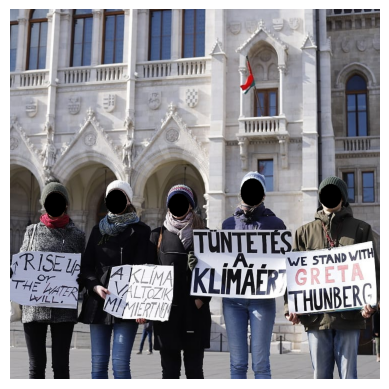

Detected 4 face(s)


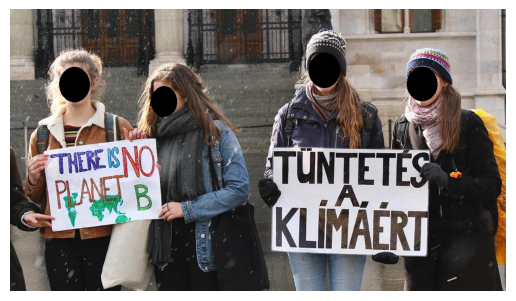

Detected 1 face(s)


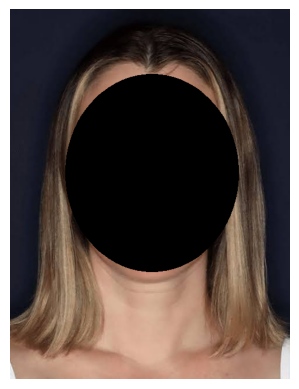

Detected 2 face(s)


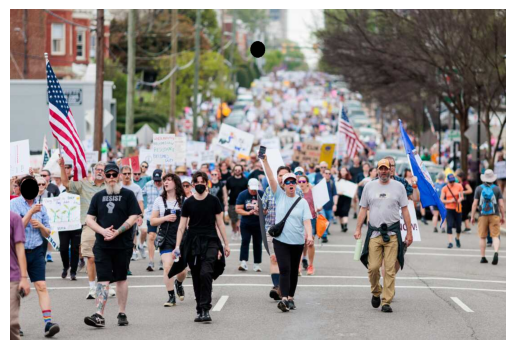

Detected 0 face(s)


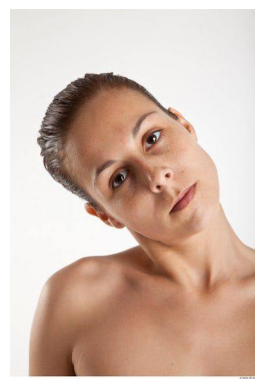

Detected 1 face(s)


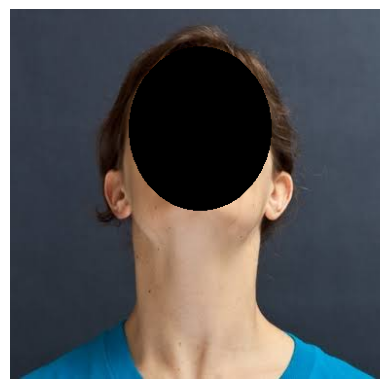

In [96]:
for image_file in image_paths:
    # 'blur', 'pixelate', 'block'
    image = obstruct_faces(image_file, obstruction_type='block')
    plotImages(image)

In [ ]:
output_dir = "images/block"
os.makedirs(output_dir, exist_ok=True)

for image_file in image_paths:

    image = obstruct_faces(
        image_file,
        obstruction_type="block"
    )

    filename = os.path.basename(image_file)
    new_path = os.path.join(output_dir, filename)

    image_bgr = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2BGR
    )

    cv2.imwrite(new_path, image_bgr)

    plotImages(image)

    print(f"Saved: {new_path}")